In [29]:
from qiskit_ibm_runtime import QiskitRuntimeService

token = "e8c9d35966cfbb9baeef4de2cbeacd0ae6f0e17de37abcc5d086f5265e60a4a56c2435f8ae6e7197c3cc68172e84d9e2499a2f77be514b4882e457b0e077fd94"

QiskitRuntimeService.save_account(
    token=token,
    channel="ibm_quantum",# `channel` distinguishes between different account types
    set_as_default=True,
    overwrite=True
)


from qiskit import QuantumCircuit,transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# Load saved credentials
service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False)

In [30]:
import sys,os

# Get the absolute path of the project's root directory
cd = os.path.abspath(os.path.join(os.path.dirname("Qiskit-cloud-supermarq"), '..'))

# Add the utils and models directories to sys.path
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks/supermarq/benchmarks'))
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks/supermarq'))
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks'))

In [31]:
from plotting import *
from converters import *
from benchmarks import GHZ, BitCode, HamiltonianSimulation, MerminBell, PhaseCode, QAOAFermionicSwapProxy, QAOAVanillaProxy, VQEProxy

In [32]:
qubits = 12
shots=1000

In [62]:
import time
sampler = Sampler(backend)
def run(benchmark_class,qubits,shots,name):
    
    benchmark_obj = benchmark_class(qubits)
    label = str(name)+"_"+str(qubits)
    print("label :",label)
    # Calculate Creation time 
    t_c = time.time()
    qc= benchmark_obj.qiskit_circuit()
    creation_time = time.time()-t_c  #in sec
    #print(qc)

    qc = transpile(qc, backend=backend, optimization_level=3)

    # Calculate Execution time 
    t_e = time.time()
    #job = sampler.run([qc], shots=shots)
    # result = job.result()
    # execution_time = time.time() - t_e #in sec
    # #print(result)
    
    # # Calculate quantum processing time 
    # quantum_time = (job.usage()) #in sec

    # #finding creg
    # reg = qc.cregs[0].name
    # #print("quantum time (s):",quantum_time)
    # counts = result[0].data[reg].get_counts()
    
    # print("counts : ",counts)
    # score = benchmark_obj.score(counts)
    # print("Score : ",score)

    # print(f"Creation, execution and Quantum Times = {creation_time},{execution_time} & {quantum_time} seconds")

    # benchmark_name = f"{name}-{qubits}"
    # plot_results([score],[benchmark_name])

    features = [
    compute_communication_with_qiskit(qc),
    compute_depth_with_qiskit(qc),
    compute_entanglement_with_qiskit(qc),
    compute_liveness_with_qiskit(qc),
    compute_measurement_with_qiskit(qc),
    compute_parallelism_with_qiskit(qc),
    ]

    label = str(name)+"_"+str(qubits)
    Features = dict()
    Features[label] = features
    print("Features :",Features)

    benchmark_features[label] = [
    compute_communication_with_qiskit(qc),
    compute_depth_with_qiskit(qc),
    compute_entanglement_with_qiskit(qc),
    compute_liveness_with_qiskit(qc),
    compute_measurement_with_qiskit(qc),
    compute_parallelism_with_qiskit(qc),
    ]
    print(benchmark_features)

    # plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
    #                spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )
    

# GHZ :

In [63]:
run(GHZ,qubits=qubits,shots=shots,name="GHZ")

label : GHZ_12
Features : {'GHZ_12': [0.0013748281464816899, 1.0, 0.09565217391304348, 0.018734727124626663, 0.0, 0.008075744917850182]}
{'ghz12': [0.4, 1.0, 0.8, 0.4666666666666667, 0.0, 0], 'hsim12': [0.16666666666666666, 1.0, 0.3188405797101449, 0.23198198198198197, 0.0, 0.07862407862407862], 'mb12': [1.0, 0.5591397849462365, 0.7209302325581395, 0.33620689655172414, 0.0, 0.11128526645768023], 'QAOAF12': [0.16666666666666666, 0.18181818181818182, 0.6875, 0.8137254901960784, 0.0, 0.42245989304812837], 'QAOAV12': [1.0, 0.4090909090909091, 0.5945945945945946, 0.3630952380952381, 0.0, 0.14935064935064934], 'GHZ_12': [0.0013748281464816899, 1.0, 0.09565217391304348, 0.01740571902196436, 0.0, 0.008075744917850182]}


In [57]:
run(GHZ,qubits=qubits,shots=shots,name="GHZ")

label : GHZ_12
{'ghz12': [0.4, 1.0, 0.8, 0.4666666666666667, 0.0, 0], 'hsim12': [0.16666666666666666, 1.0, 0.3188405797101449, 0.23198198198198197, 0.0, 0.07862407862407862], 'mb12': [1.0, 0.5591397849462365, 0.7209302325581395, 0.33620689655172414, 0.0, 0.11128526645768023], 'QAOAF12': [0.16666666666666666, 0.18181818181818182, 0.6875, 0.8137254901960784, 0.0, 0.42245989304812837], 'QAOAV12': [1.0, 0.4090909090909091, 0.5945945945945946, 0.3630952380952381, 0.0, 0.14935064935064934], 'GHZ_12': [0.0013748281464816899, 1.0, 0.09565217391304348, 0.018734727124626663, 0.0, 0.008075744917850182]}


# Bitcode

In [7]:
# # '''
# #     Args:
# #         num_data: The number of data qubits.
# #         num_rounds: The number of measurement rounds.
# #         bit_state: A list denoting the state to initialize each data qubit to.

# #     Returns:
# #         A `cirq.Circuit` for the bit-flip error correcting code.
# # '''

# # num_data_qubits = 3
# # num_rounds = 1
# # bit_state = [1, 1, 1]

# qubits = 3

# bc = BitCode(3,1,[1,1,1])
# bc_ckt = bc.circuit()
# #only Cirq's implementation for ckt creation
# bc_ckt = cirq_to_qiskit(bc_ckt)
# print(bc_ckt)

# job = execute(bc_ckt, backend, shots=shots, **options)
# counts = job.result().results[0]#.data.partial_probability
# print(counts)
# for key in counts.keys():
#     counts[key] = int(counts[key] * shots)
    
# print("counts : ",counts)
# score = bc.score(counts)
# print("Score : ",score)

# name = "Bitcode"

# benchmark_name = f"{name}-{qubits}"
# plot_results([score],[benchmark_name])

# features = [
# compute_communication_with_qiskit(bc_ckt),
# compute_depth_with_qiskit(bc_ckt),
# compute_entanglement_with_qiskit(bc_ckt),
# compute_liveness_with_qiskit(bc_ckt),
# compute_measurement_with_qiskit(bc_ckt),
# compute_parallelism_with_qiskit(bc_ckt),
# ]
# print("Features :",features)

# plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
#                    spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )

# Hamiltonian_Simulation:

counts :  {'111111111101': 2, '110111010011': 1, '111110011110': 4, '111110111001': 11, '111110111111': 82, '010110111111': 2, '111110110010': 6, '111000011111': 1, '110110111110': 12, '111011110011': 1, '111110011001': 1, '111111111110': 11, '011111001111': 1, '111110110011': 8, '111110011010': 1, '011110111011': 9, '111110101011': 11, '011110101111': 3, '011111011011': 1, '101010111111': 2, '001110111000': 1, '110110111111': 25, '110110111011': 6, '111110111110': 43, '011110101101': 1, '000110101011': 1, '111011111101': 2, '111111111001': 2, '101110111110': 6, '111000111111': 2, '111110101001': 5, '011110111111': 12, '111101111111': 12, '100111011110': 1, '110110100110': 1, '011010111110': 2, '101110111010': 7, '111101101111': 3, '110110011111': 3, '101110111001': 2, '110110111010': 9, '001110011100': 1, '011111011111': 3, '111000111011': 1, '111011010111': 1, '011001111111': 1, '111110111010': 22, '111101111010': 3, '101110111111': 9, '111010100011': 1, '111110111011': 44, '01011011

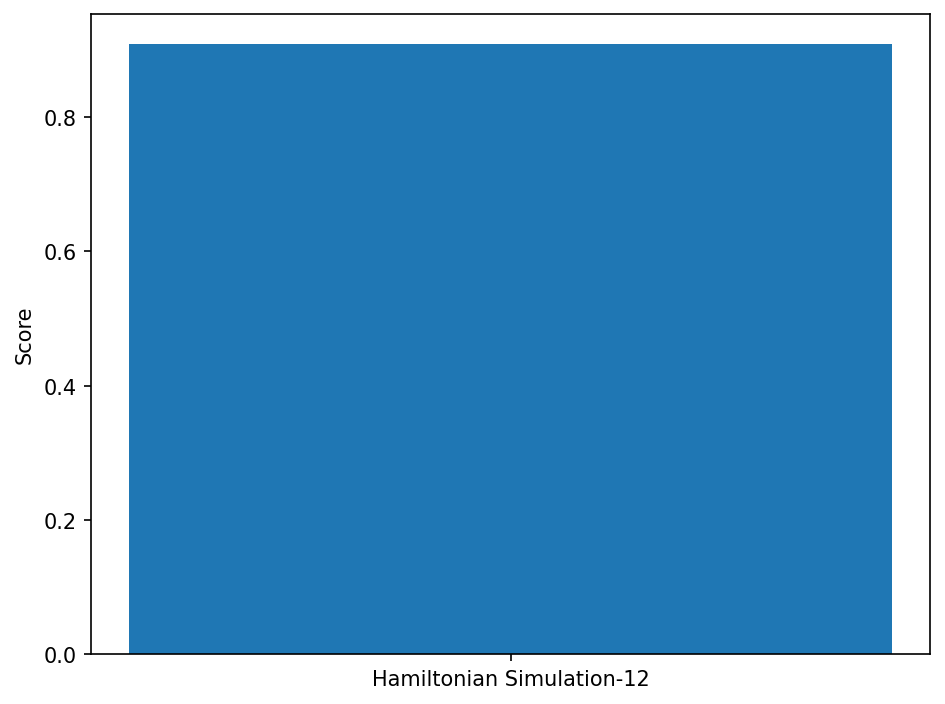

Features : [0.0013748281464816899, 1.0, 0.10576923076923077, 0.02564102564102564, 0.0, 0.013784461152882206]


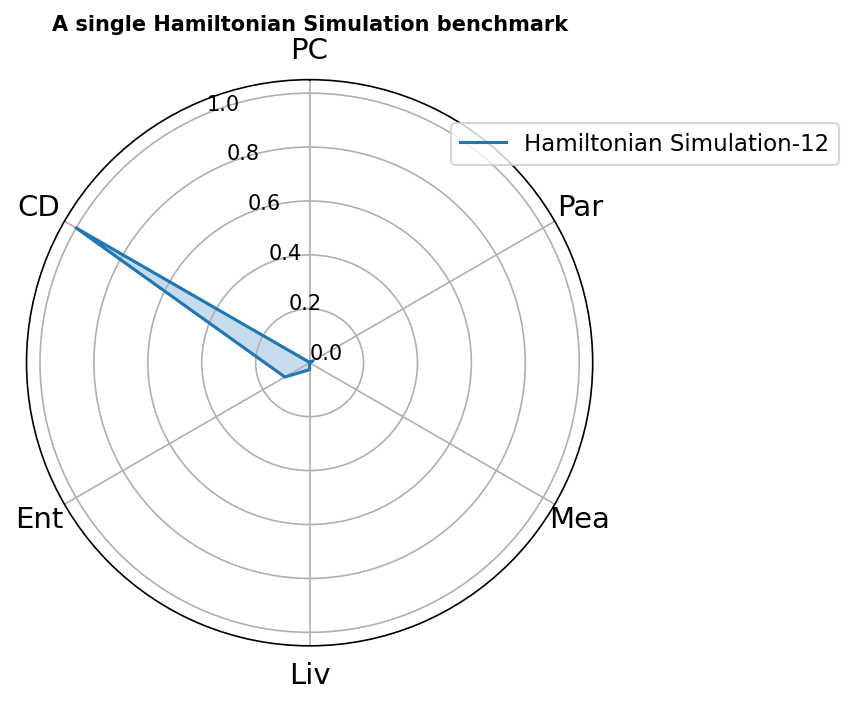

In [8]:
run(HamiltonianSimulation,qubits=qubits,shots=shots,name="Hamiltonian Simulation")

# MerminBell

counts :  {'000100011000': 1, '010110010011': 1, '011101101101': 1, '101101100011': 1, '111101000011': 1, '101000001000': 1, '100001001011': 1, '110101110011': 1, '010100100001': 2, '110011000010': 1, '111010011111': 1, '111100110110': 2, '110011100100': 1, '111001010110': 2, '000001000011': 1, '000010000001': 1, '100000001111': 1, '010010111100': 1, '101111111000': 1, '011110001001': 2, '110110110110': 1, '010100100110': 1, '101000001111': 1, '001111001110': 1, '011100111111': 1, '011101100110': 2, '110101110111': 1, '101000111111': 1, '110011100011': 1, '011110111101': 2, '010000011010': 1, '101111001000': 1, '011000000111': 1, '000111001001': 1, '001010011101': 1, '001011110011': 1, '010001000101': 1, '110111101011': 1, '001101100000': 1, '110010100010': 1, '100110101100': 1, '001000111111': 1, '101001100000': 1, '111010100100': 1, '001101101110': 1, '101111110000': 1, '001000011011': 1, '111000101111': 1, '100100010011': 1, '010101100011': 3, '100101110010': 2, '101111100010': 1, '

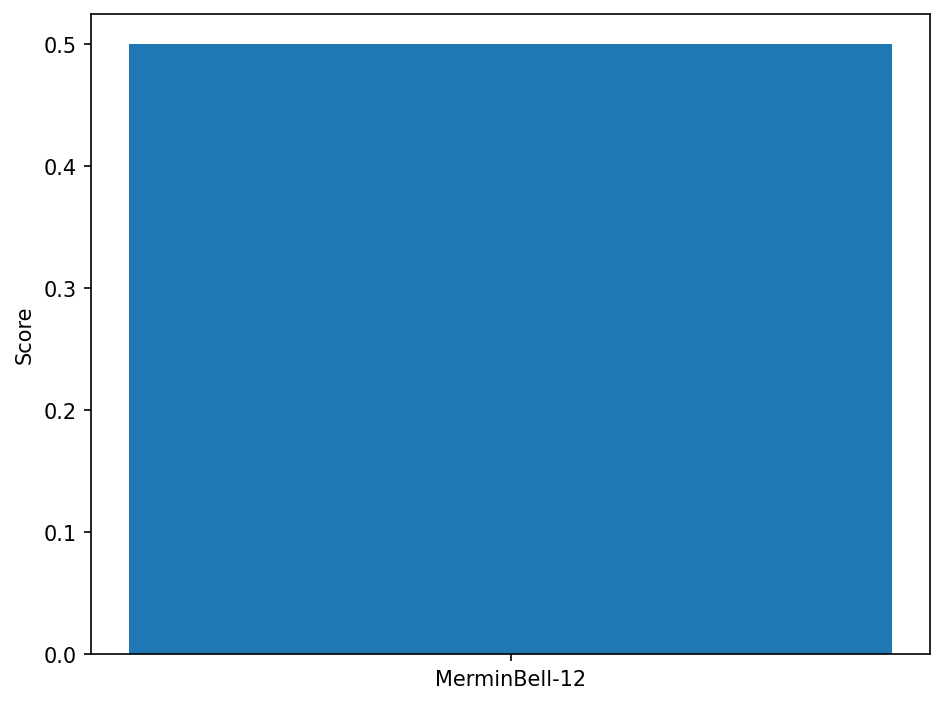

Features : [0.0013748281464816899, 0.6655518394648829, 0.1625883632408918, 0.020874394399836887, 0.0, 0.01008230452674897]


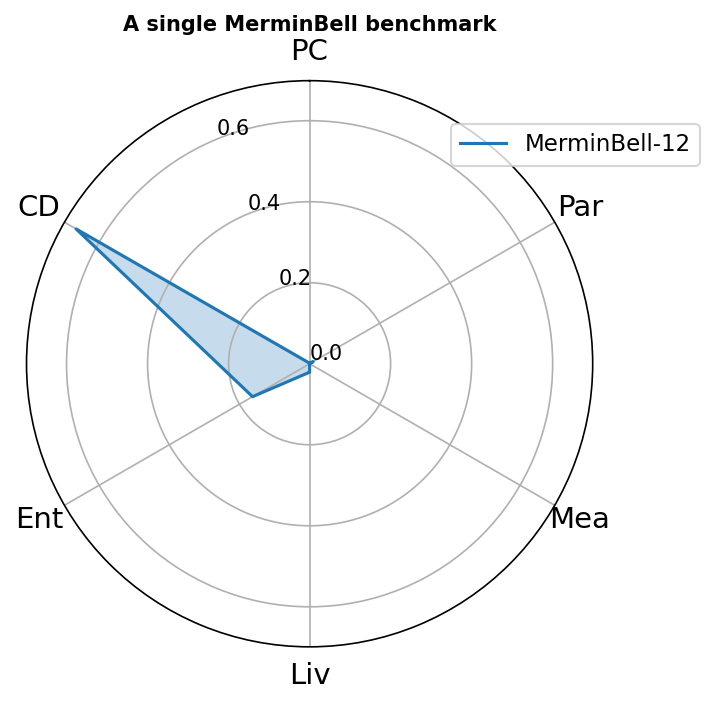

In [18]:
run(MerminBell,qubits=qubits,shots=shots,name="MerminBell")

# PhaseCode :

In [ ]:
# # Only cirq circuit implementation is given


# # num_data_qubits = 3
# # num_rounds = 1
# # phase_state = [1, 1, 1]

# qubits = 3

# pc = PhaseCode(3, 1, [1, 1, 1])
# pc_ckt = bc.circuit()
# #only Cirq's implementation for ckt creation
# pc_ckt = cirq_to_qiskit(pc_ckt)
# print(pc_ckt)

# job = execute(pc_ckt, backend, shots=shots, **options)
# counts = job.result().results[0].data.partial_probability
# for key in counts.keys():
#     counts[key] = int(counts[key] * shots)
    
# print("counts : ",counts)
# score = pc.score(counts)
# print("Score : ",score)

# name = "Bitcode"

# benchmark_name = f"{name}-{qubits}"
# plot_results([score],[benchmark_name])

# features = [
# compute_communication_with_qiskit(pc_ckt),
# compute_depth_with_qiskit(pc_ckt),
# compute_entanglement_with_qiskit(pc_ckt),
# compute_liveness_with_qiskit(pc_ckt),
# compute_measurement_with_qiskit(pc_ckt),
# compute_parallelism_with_qiskit(pc_ckt),
# ]
# print("Features :",features)

# plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
#                    spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )

#  QAOAFermionicSwapProxy:

counts :  {'001001010000': 1, '100111000100': 1, '111011000100': 2, '011010011100': 1, '001000101001': 1, '110010010100': 1, '000010010001': 1, '110110100001': 1, '000111010101': 1, '010100000001': 1, '000111010000': 4, '111100101010': 1, '011101000001': 4, '100100100010': 1, '001100000110': 2, '100101000010': 3, '000001000101': 2, '001101100000': 1, '010101010010': 1, '000111000110': 4, '011100111001': 2, '011000011100': 2, '011100010000': 3, '010100100001': 3, '110001001100': 1, '100000000011': 3, '101000101011': 2, '000111011100': 3, '001111110100': 2, '011100010110': 4, '110000010001': 1, '001101010000': 3, '010101001110': 1, '000110100111': 1, '011111000001': 1, '000001100001': 1, '100011000001': 1, '001100010010': 3, '011101000101': 2, '111010100100': 1, '110100100011': 1, '000111110100': 2, '101101000001': 1, '000000010100': 1, '010001100101': 1, '111001011101': 1, '110000010111': 1, '000001000011': 4, '110000000011': 1, '000000100011': 1, '000100010000': 1, '111000000101': 5, '

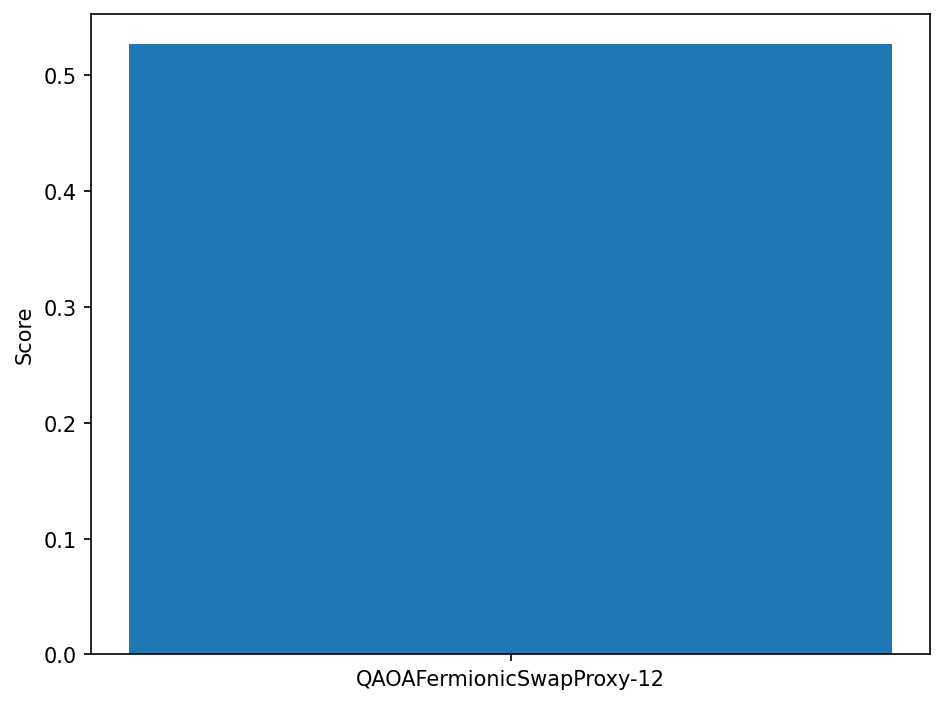

Features : [0.0013748281464816899, 0.18181818181818182, 0.17142857142857143, 0.07071073352673021, 0.0, 0.05276989382949648]


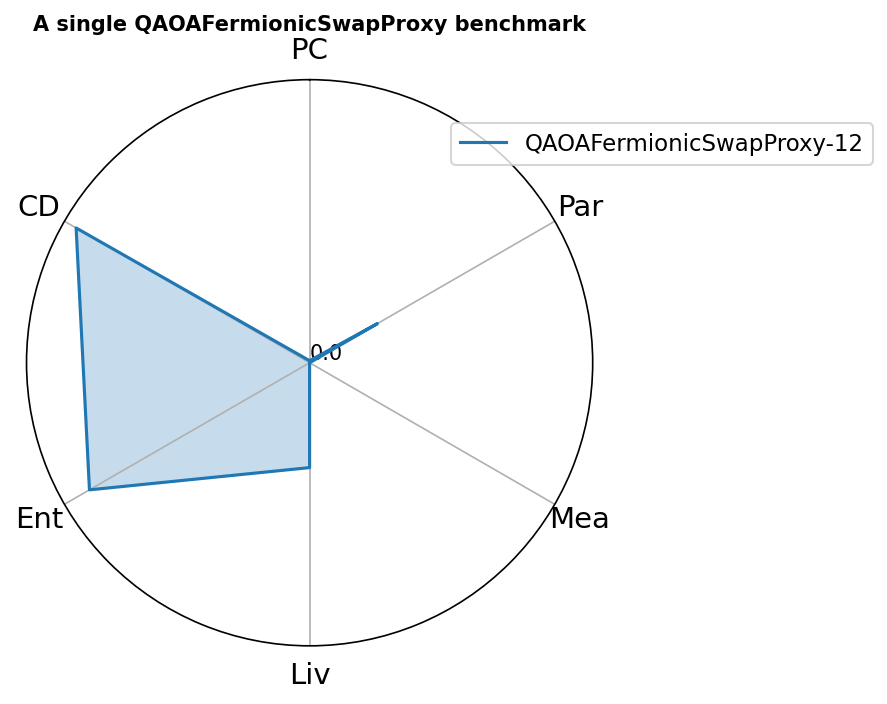

In [19]:
run(QAOAFermionicSwapProxy,qubits=qubits,shots=shots,name="QAOAFermionicSwapProxy")

# QAOAVanillaProxy :

counts :  {'110100101111': 1, '010101000101': 1, '101111100111': 1, '000010111101': 1, '000111111001': 2, '011111101001': 1, '001000010110': 1, '010111010101': 2, '110000101000': 1, '001110001101': 1, '110101101101': 1, '110000010111': 1, '100000110111': 2, '010101111001': 1, '110111100010': 2, '111001010000': 2, '110010001010': 1, '010010110000': 1, '100001011010': 2, '011010101110': 1, '110010100011': 1, '100001010011': 2, '000001011010': 1, '111000110100': 1, '111001100110': 1, '001010001111': 1, '010001110010': 1, '101110111111': 1, '011101011110': 1, '101011111000': 3, '011000010011': 1, '110010111101': 1, '001010011000': 2, '011000001101': 1, '001111001111': 1, '110011111010': 1, '001111111010': 2, '000110011000': 1, '110110011101': 2, '110000000110': 1, '110001010000': 1, '011010111101': 1, '001011100100': 1, '101010001001': 1, '001110101010': 1, '111100101000': 1, '000000010011': 2, '111111100011': 1, '100010100101': 1, '011001110101': 1, '010010111100': 1, '110100100000': 2, '

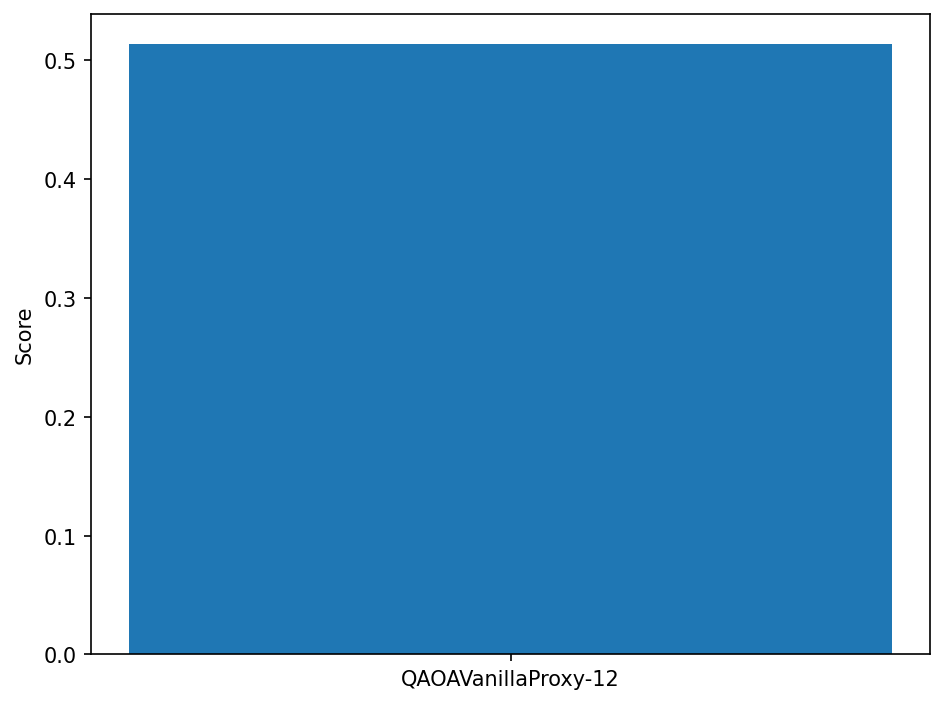

Features : [0.0013748281464816899, 0.49279538904899134, 0.18101199791340636, 0.02635479388605836, 0.0, 0.014470392968183839]


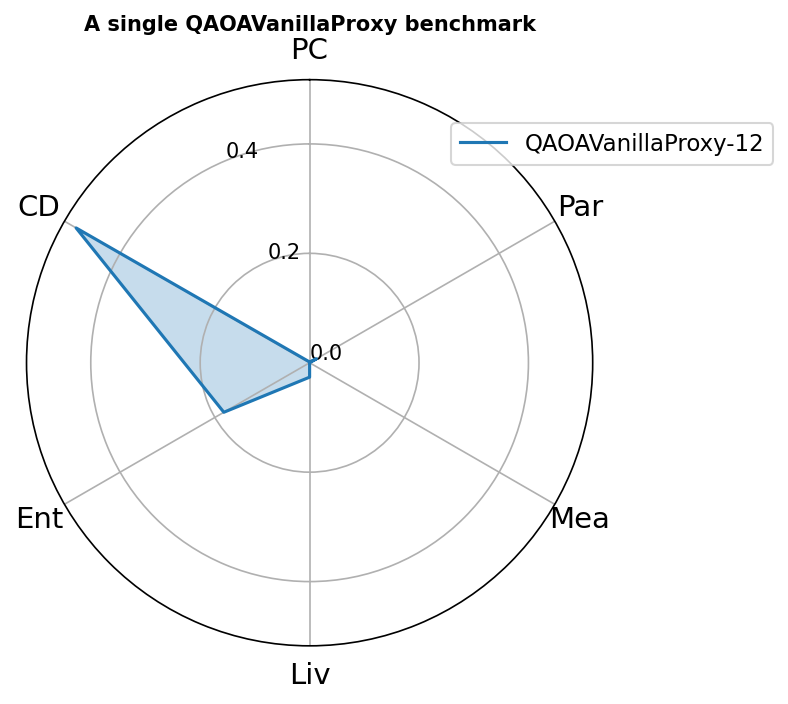

In [20]:
run(QAOAVanillaProxy,qubits=qubits,shots=shots,name="QAOAVanillaProxy")

# VQEProxy:

 Creation time for 2 circuits = 4.103534698486328 sec
0: ───Ry(-0.616π)───Rz(-1.04π)───@───Ry(1.2π)───Rz(0.933π)────────────────────────────────────────────────────M───
                                 │                                                                            │
1: ───Ry(-1.46π)────Rz(-2.0π)────X───@──────────Ry(-0.293π)───Rz(-2.0π)───────────────────────────────────────M───
                                     │                                                                        │
2: ───Ry(-0.542π)───Rz(-π)───────────X──────────@─────────────Ry(-1.3π)───Rz(0)───────────────────────────────M───
                                                │                                                             │
3: ───Ry(0.458π)────Rz(π)───────────────────────X─────────────@───────────Ry(-1.31π)───Rz(0)──────────────────M───
                                                              │                                               │
4: ───Ry(-0.541π)───Rz(π)─────────────

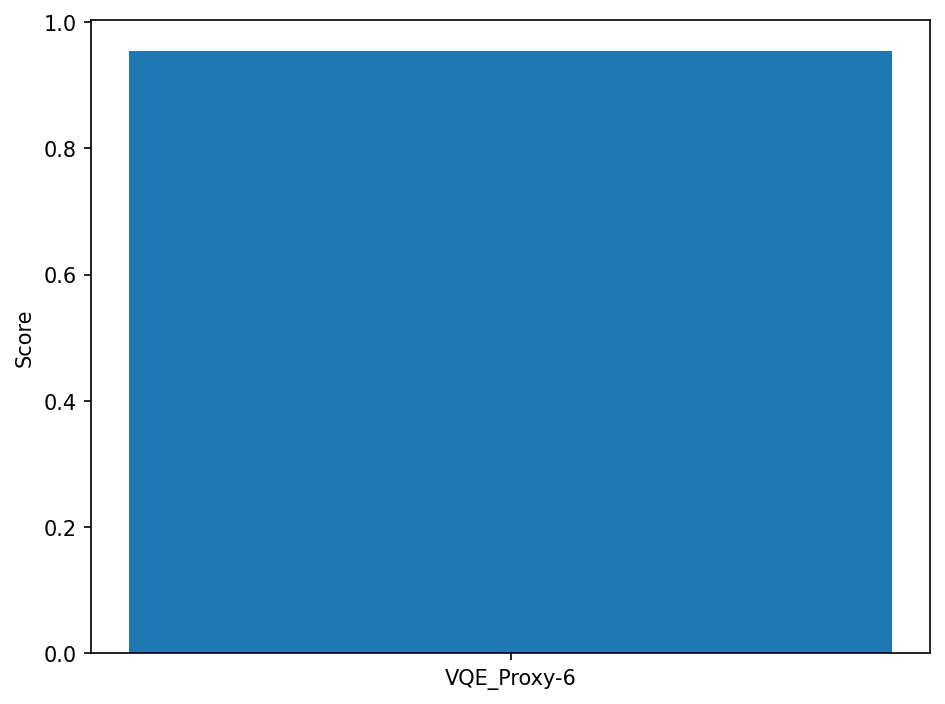

Features for ckt circuit-183: [0.3333333333333333, 1.0, 0.1724137931034483, 0.6666666666666666, 0.0, 0.4444444444444445]


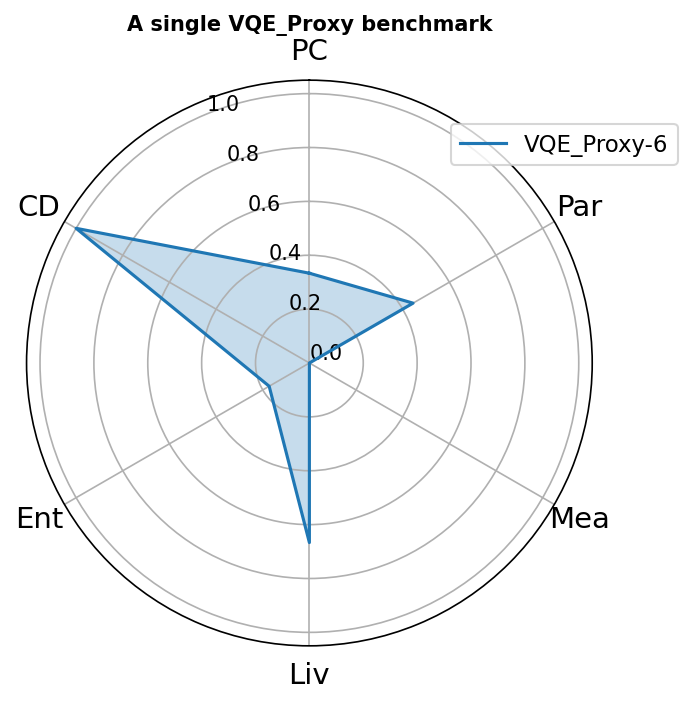

Features for ckt circuit-185: [0.3333333333333333, 1.0, 0.14285714285714285, 0.696969696969697, 0.0, 0.5]


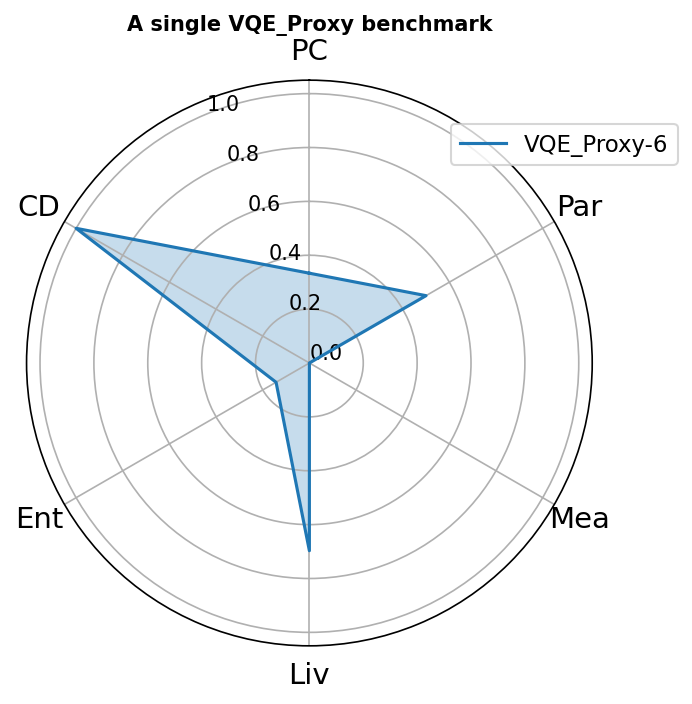

In [21]:
import simulation,time

final_counts = []
ckt_list = []

# Calculate Creation time 
t_c = time.time()
#vqe = VQEProxy(3, 1) #3 Qubits, 1 Layer
vqe = VQEProxy(6, 1)
shots = 1000
ckts =  vqe.circuit()
creation_time = time.time()-t_c

for i in ckts:
    ckt_list.append(cirq_to_qiskit(i))

print(f" Creation time for {len(ckt_list)} circuits = {creation_time} sec")

for i in ckts:
    print(i)


for i in ckt_list:
    # Calculate Execution time 
    t_e = time.time()
    qc = transpile(i, backend=backend, optimization_level=3)
    job = sampler.run([qc], shots=shots)
    result = job.result()
    execution_time = time.time() - t_e #in sec

    # Calculate quantum processing time 
    quantum_time = (job.usage()) #in sec

    print(f" For circuit i={i}, execution time = {execution_time} sec and quantum time = {quantum_time} sec")
    
    #finding creg
    reg = qc.cregs[0].name
    #print("quantum time (s):",quantum_time)
    counts = result[0].data[reg].get_counts()
    print("counts : ",counts)

    final_counts.append(counts)

print("Final Counts:",final_counts)
print("########################################################")
score_vqe = vqe.score(final_counts)
print(score_vqe)

name = "VQE_Proxy"
qubits = vqe.num_qubits

benchmark_name = f"{name}-{qubits}"
plot_results([score_vqe],[benchmark_name])

for i in ckt_list:
    features = [
    compute_communication_with_qiskit(i),
    compute_depth_with_qiskit(i),
    compute_entanglement_with_qiskit(i),
    compute_liveness_with_qiskit(i),
    compute_measurement_with_qiskit(i),
    compute_parallelism_with_qiskit(i),
    ]
    print(f"Features for ckt {i.name}: {features}")
    
    plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
                       spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )
    

# correlation Plots :

In [54]:
# from benchmarks import GHZ,BitCode,HamiltonianSimulation,MerminBell, PhaseCode, QAOAFermionicSwapProxy, QAOAVanillaProxy, VQEProxy
# benchmark_features = {}
# benchmarks_list = [
#     (GHZ(5), "ghz12"),
#     (HamiltonianSimulation(12), "hsim12"),
#     (MerminBell(12), "mb12"),
#     (QAOAFermionicSwapProxy(12), "QAOAF12"),
#     (QAOAVanillaProxy(12), "QAOAV12"),
#     (VQEProxy(12),"VQE12")
# ]
# for benchmark, label in benchmarks_list:
#     benchmark_features[label] = [
#         compute_communication_with_qiskit(benchmark.qiskit_circuit()),
#         compute_depth_with_qiskit(benchmark.qiskit_circuit()),
#         compute_entanglement_with_qiskit(benchmark.qiskit_circuit()),
#         compute_liveness_with_qiskit(benchmark.qiskit_circuit()),
#         compute_measurement_with_qiskit(benchmark.qiskit_circuit()),
#         compute_parallelism_with_qiskit(benchmark.qiskit_circuit()),
#     ]
# print(benchmark_features)

In [10]:
g = GHZ(12)
g.num_qubits

12

NameError: name 'ghz' is not defined

In [ ]:
jobs = []
for benchmark, label in benchmarks_list:
    job = execute(benchmark.qiskit_circuit(), backend, shots=shots, **options)
    jobs.append((label, job, benchmark))

device_scores = {}

for label, job, benchmark in jobs:
    if job.status() == qiskit.providers.jobstatus.JobStatus.DONE:
        counts = job.result().results[0].data.partial_probability
        for key in counts.keys():
            counts[key] = int(counts[key] * shots)
        print(counts)
        score = benchmark.score(counts)
        print(score)
        device_scores[label] = score
    else:
        print(label, "not done!")

In [ ]:
plot_correlations(
    benchmark_features,
    device_scores,
    ["PC", "CD", "Ent", "Liv", "Mea", "Par"],
    device_name="ibmq_sim",
)

In [ ]:
# Full code with modifications (qubit numbers for labels and annotated bar values)

# Create subplots for each circuit group with a logarithmic scale on the y-axis

# Data grouped by circuits
circuit_groups = {
    'GHZ': ['GHZ_3', 'GHZ_6', 'GHZ_9', 'GHZ_12'],
    'Hamiltonian': ['Hamiltonian_3', 'Hamiltonian_6', 'Hamiltonian_9', 'Hamiltonian_12'],
    'MerminBell': ['MerminBell_3', 'MerminBell_6', 'MerminBell_9', 'MerminBell_12'],
    'QAOAFermonicsSwapProxy': ['QAOAFermonicsSwapProxy_3', 'QAOAFermonicsSwapProxy_6', 'QAOAFermonicsSwapProxy_9', 'QAOAFermonicsSwapProxy_12'],
    'QAOAVanillaProxy': ['QAOAVanillaProxy_3', 'QAOAVanillaProxy_6', 'QAOAVanillaProxy_9', 'QAOAVanillaProxy_12'],
    'VQEProxy': ['VQEProxy_3-1', 'VQEProxy_6-1', 'VQEProxy_9-1', 'VQEProxy_12-1']
}

# Times grouped by the corresponding circuits
times_grouped = {
    'GHZ': {
        'creation': [0.00019, 0.00024, 0.00031, 0.00035],
        'execution': [0.00487, 0.09619, 2.41722, 194.82283],
        'quantum': [0.00183, 0.02746, 2.34878, 194.75516]
    },
    'Hamiltonian': {
        'creation': [0.00031, 0.00081, 0.00112, 0.00083],
        'execution': [0.05904, 0.04215, 2.63808, 228.08030],
        'quantum': [0.00117, 0.03203, 2.62990, 228.06959]
    },
    'MerminBell': {
        'creation': [0.02286, 0.03448, 0.06045, 0.32621],
        'execution': [0.07229, 0.04377, 2.97377, 258.73765],
        'quantum': [0.00145, 0.03613, 2.96286, 258.72209]
    },
    'QAOAFermonicsSwapProxy': {
        'creation': [0.01791, 0.02336, 0.03064, 0.04304],
        'execution': [0.00607, 0.04839, 4.15135, 441.74792],
        'quantum': [0.00167, 0.04126, 4.13894, 441.71516]
    },
    'QAOAVanillaProxy': {
        'creation': [0.01759, 0.02100, 0.02737, 0.03923],
        'execution': [0.00563, 0.04588, 4.33030, 515.19666],
        'quantum': [0.00144, 0.03895, 4.31959, 515.17890]
    },
    'VQEProxy': {
        'creation': [3.85057, 8.87647, 32.83943, 239.10041],
        'execution': [0.01231, 0.08357, 5.62762, 442.46407],
        'quantum': [0.00197, 0.06786, 5.60681, 442.43366]
    }
}

# Create subplots
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

axes = []
for i in range(6):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    axes.append(ax)

# Plot the data in each subplot
for i, (group, data) in enumerate(times_grouped.items()):
    x = np.arange(len(data['creation']))
    bar_width = 0.2
    
    # Create bars for each time category (Creation, Execution, Quantum)
    bars1 = axes[i].bar(x - bar_width, data['creation'], bar_width, label='Creation Time', color='skyblue')
    bars2 = axes[i].bar(x, data['execution'], bar_width, label='Execution Time', color='lightgreen')
    bars3 = axes[i].bar(x + bar_width, data['quantum'], bar_width, label='Quantum Time', color='lightcoral')

    # Set title and labels
    axes[i].set_title(group)
    axes[i].set_xticks(x)
    # Set x-axis labels to just qubit numbers
    axes[i].set_xticklabels(['3', '6', '9', '12'], rotation=0)

    # Use a logarithmic scale for the y-axis
    axes[i].set_yscale('log')
    axes[i].set_ylabel('Time (s)')
    axes[i].set_xlabel(' Number of Qubits ')

    # Annotate each bar with its value
    for bar in bars1 + bars2 + bars3:
        yval = bar.get_height()
        rotation = 90
        if yval > 0:  # To avoid annotation of zero values
            axes[i].text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 5),
                         ha='center', va='bottom', fontsize=8, rotation=rotation)

    # Add a legend to the first plot
    if i == 0:
        axes[i].legend()

# Set overall title and show the plot
fig.suptitle('CPU Execution Times (Logarithmic Scale)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("SupermarQ_DM.jpg",dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# Data grouped by circuits
circuit_groups = {
    'GHZ': ['GHZ_3', 'GHZ_6', 'GHZ_9', 'GHZ_12', 'GHZ_15'],
    'Hamiltonian': ['Hamiltonian_3', 'Hamiltonian_6', 'Hamiltonian_9', 'Hamiltonian_12', 'Hamiltonian_15'],
    'MerminBell': ['MerminBell_3', 'MerminBell_6', 'MerminBell_9', 'MerminBell_12', 'MerminBell_15'],
    'QAOAFermonicsSwapProxy': ['QAOAFermonicsSwapProxy_3', 'QAOAFermonicsSwapProxy_6', 'QAOAFermonicsSwapProxy_9', 'QAOAFermonicsSwapProxy_12', 'QAOAFermonicsSwapProxy_15'],
    'QAOAVanillaProxy': ['QAOAVanillaProxy_3', 'QAOAVanillaProxy_6', 'QAOAVanillaProxy_9', 'QAOAVanillaProxy_12', 'QAOAVanillaProxy_15'],
    'VQEProxy': ['VQEProxy_3-1', 'VQEProxy_6-1', 'VQEProxy_9-1', 'VQEProxy_12-1', 'VQEProxy_15_1']
}

# Times grouped by the corresponding circuits
times_grouped = {
    'GHZ': {
        'creation': [0.00077, 0.00571, 0.00749, 0.00146, 0.00549],
        'execution': [2.34516, 2.46811, 6.10604, 123.19916, 3657.78175],
        'quantum': [2.19114, 2.44970, 5.91542, 123.09776, 3657.61055]
    },
    'Hamiltonian': {
        'creation': [0.00988, 0.00605, 0.00366, 0.00237, 0.00625],
        'execution': [0.89308, 3.05902, 3.58553, 86.30175, 3990.54108],
        'quantum': [0.83668, 3.01967, 3.48032, 86.27897, 3990.48710]
    },
    'MerminBell': {
        'creation': [0.11939, 0.13703, 0.16311, 0.66666, 4.76282],
        'execution': [0.81898, 2.77348, 3.96414, 110.71350, 3432.47750],
        'quantum': [0.76709, 2.73125, 3.92975, 110.64262, 3432.43987]
    },
    'QAOAFermonicsSwapProxy': {
        'creation': [0.04632, 0.09116, 0.10303, 0.07654, 0.09134],
        'execution': [0.48518, 2.56128, 5.16314, 94.98028, 3733.60160],
        'quantum': [0.45896, 2.50908, 5.09258, 94.94145, 3733.55394]
    },
    'QAOAVanillaProxy': {
        'creation': [0.04888, 0.07390, 2.54550, 0.08455, 0.07949],
        'execution': [0.61416, 2.70635, 3.02623, 105.05634, 3367.11107],
        'quantum': [0.58746, 2.65452, 2.99742, 104.99792, 3367.06934]
    },
    'VQEProxy': {
        'creation': [5.07935, 9.71754, 18.27496, 69.58008, 460.38682],
        'execution': [1.02432, 5.00333, 3.95951, 199.89572, 7230.93847],
        'quantum': [0.96689, 4.89941, 3.87721, 199.83086, 7230.39151]
    }
}

# Create subplots
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

axes = []
for i in range(6):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    axes.append(ax)

# Plot the data in each subplot
for i, (group, data) in enumerate(times_grouped.items()):
    x = np.arange(len(data['creation']))
    bar_width = 0.2
    
    # Create bars for each time category (Creation, Execution, Quantum)
    bars1 = axes[i].bar(x - bar_width, data['creation'], bar_width, label='Creation Time', color='skyblue')
    bars2 = axes[i].bar(x, data['execution'], bar_width, label='Execution Time', color='lightgreen')
    bars3 = axes[i].bar(x + bar_width, data['quantum'], bar_width, label='Quantum Time', color='lightcoral')

    # Set title and labels
    axes[i].set_title(group)
    axes[i].set_xticks(x)
    # Set x-axis labels to just qubit numbers
    axes[i].set_xticklabels(['3', '6', '9', '12', '15'], rotation=0)

    # Use a logarithmic scale for the y-axis
    axes[i].set_yscale('log')
    axes[i].set_ylabel('Time (s)')
    axes[i].set_xlabel(' Number of Qubits ')

    # Annotate each bar with its value
    for bar in bars1 + bars2 + bars3:
        yval = bar.get_height()
        rotation = 90
        if yval > 0:  # To avoid annotation of zero values
            axes[i].text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 5),
                         ha='center', va='bottom', fontsize=8, rotation=rotation)

    # Add a legend to the first plot
    if i == 0:
        axes[i].legend()

# Set overall title and show the plot
fig.suptitle('GPU Execution Times (Logarithmic Scale)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("SupermarQ_DM_GPU.jpg",dpi=600, bbox_inches='tight')
plt.show()
